# Hi there, here's how to make this notebook work:

First, go through the yarp-again installation detailed on the README page.
- Link to github: [https://github.com/Savoie-Research-Group/yarp-again]

Second, checkout this branch/commit:
- branch: `enum`
- commit: `d20bc6e`

In [1]:
import yarp as yp
from yarp.reaction.enum import break_bonds, form_n_bonds

import numpy as np
import cProfile
import pstats

In [2]:
def run_stats(command, cutoff=30):
    # Show top functions by cumulative time
    cProfile.run(command, 'tmp.prof')

    p = pstats.Stats('tmp.prof')
    p.sort_stats('cumtime').print_stats(cutoff)  

    return

In [3]:
def check_resonance(mol_list):
    mols = []
    count = 0
    N_res = []
    for mol in mol_list:
        if len(mol.bond_mat_scores) > 1:
            mols.append(mol)
            N_res.append(len(mol.bond_mat_scores))
            count += len(mol.bond_mat_scores)

    print(f"Number of molecules with resonance structures: {len(N_res)}")
    print(f"Total resonance structures generated: {count}")
    if count > 0:
        print(f"  - Maximum N resonance structures: {max(N_res)}")
        print(f"  - Minimum N resonance structures: {min(N_res)}")
        print(f"  - Average N resonance structures: {sum(N_res)/len(N_res)}")
    
    return mols


# The three starting test cases

1. Diels-Alder product --> 6 heavy atoms, 10 hydrogen atoms, 1 resonance structure
2. Benzene --> 6 heavy atoms, 6 hydrogen atoms, 2 resonance structures
3. Pyridine --> 6 heavy atoms, 5 hydrogen atoms, 2 resonance structures -->

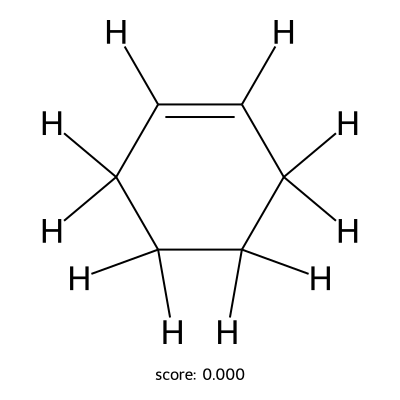

In [4]:
# da_smi = "C=C.C=CC=C"
# da_xyz = "/Users/erm/git_stuff/yarp-again/test/molecules/diels_alder.xyz"
da_smi = "C1C=CCCC1"
da_mol = yp.yarpecule(da_smi)
da_mol.draw_bmats(show_inline=True)

In [5]:
run_stats('yp.yarpecule(da_smi)')

Wed Jul  2 14:26:50 2025    tmp.prof

         6275 function calls (5386 primitive calls) in 0.018 seconds

   Ordered by: cumulative time
   List reduced from 195 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.018    0.018 {built-in method builtins.exec}
        1    0.000    0.000    0.018    0.018 <string>:1(<module>)
        1    0.000    0.000    0.018    0.018 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
        1    0.000    0.000    0.008    0.008 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:246(_order_atoms)
        1    0.000    0.000    0.008    0.008 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/atom_mapping.py:10(canon_order)
        1    0.000    0.000    0.006    0.006 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/atom_mapping.py:78(<listcomp>)
       16    0.000    0.000    0.006    0.000 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/has

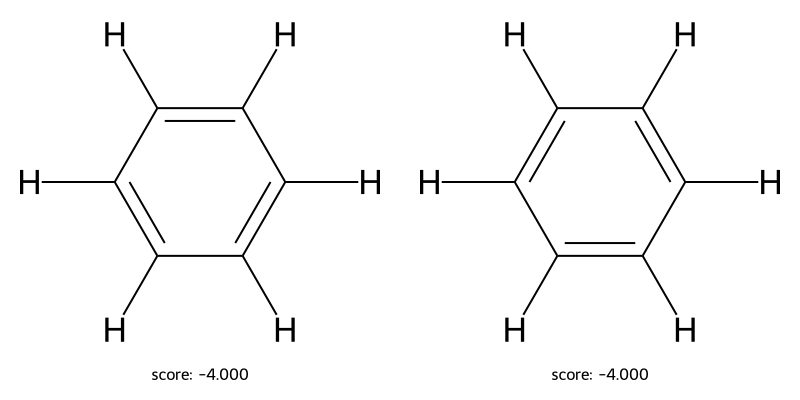

In [6]:
benzene_smi = "c1ccccc1"
benzene_mol = yp.yarpecule(benzene_smi)
benzene_mol.draw_bmats(show_inline=True)

In [7]:
run_stats('yp.yarpecule(benzene_smi)')

Wed Jul  2 14:26:50 2025    tmp.prof

         6113 function calls (5614 primitive calls) in 0.098 seconds

   Ordered by: cumulative time
   List reduced from 196 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.098    0.098 {built-in method builtins.exec}
        1    0.000    0.000    0.098    0.098 <string>:1(<module>)
        1    0.000    0.000    0.098    0.098 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
        1    0.000    0.000    0.089    0.089 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
        1    0.000    0.000    0.085    0.085 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/lewis_structure.py:80(__init__)
        1    0.000    0.000    0.068    0.068 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/lewis_structure.py:119(_find_rings)
        1    0.000    0.000    0.068    0.068 /Users/erm/git_stuff/yarp-ag

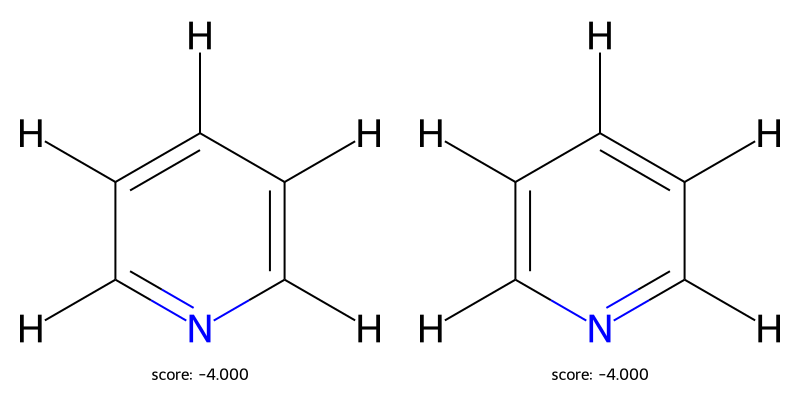

In [8]:
nbenz_smi = "n1ccccc1"
nbenz_mol = yp.yarpecule(nbenz_smi)
nbenz_mol.draw_bmats(show_inline=True)

In [9]:
run_stats('yp.yarpecule(nbenz_smi)', 50)

Wed Jul  2 14:26:50 2025    tmp.prof

         25137 function calls (24715 primitive calls) in 0.056 seconds

   Ordered by: cumulative time
   List reduced from 201 to 50 due to restriction <50>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.056    0.056 {built-in method builtins.exec}
        1    0.000    0.000    0.056    0.056 <string>:1(<module>)
        1    0.000    0.000    0.056    0.056 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
        1    0.000    0.000    0.048    0.048 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
        1    0.000    0.000    0.048    0.048 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/lewis_structure.py:80(__init__)
        1    0.000    0.000    0.047    0.047 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/lewis_structure.py:127(_gen_bond_el_mat)
      9/2    0.001    0.000    0.043    0.021 /Users/erm/git_stuff/

# Happy Path: Diels-Alder b2f2 enumeration


## Bond breakage!

In [10]:
da_break = list(break_bonds(da_mol, n=2))
print(f"We have {len(da_break)} intermediates after break 2")

We have 36 intermediates after break 2


In [11]:
run_stats('list(break_bonds(da_mol, n=2))')

Wed Jul  2 14:26:52 2025    tmp.prof

         1027140 function calls (905321 primitive calls) in 1.261 seconds

   Ordered by: cumulative time
   List reduced from 196 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    1.267    1.267 {built-in method builtins.exec}
        1    0.000    0.000    1.266    1.266 <string>:1(<module>)
       37    0.005    0.000    1.266    0.034 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:257(break_bonds)
      210    0.001    0.000    1.259    0.006 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
      210    0.002    0.000    0.912    0.004 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
      210    0.004    0.000    0.867    0.004 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/lewis_structure.py:80(__init__)
      210    0.019    0.000    0.546    0.003 /Users/erm/git_stuff/yarp-again/yarp/yarp

In [12]:
da_break_res = check_resonance(da_break)

Number of molecules with resonance structures: 8
Total resonance structures generated: 16
  - Maximum N resonance structures: 2
  - Minimum N resonance structures: 2
  - Average N resonance structures: 2.0


In [13]:
da_break = sorted(da_break, key=lambda mol: mol.bond_mat_scores[0])

# print("Top 3 break 2 intermediates:")
# da_break[0].draw_bmats(show_inline=True)
# da_break[1].draw_bmats(show_inline=True)
# da_break[2].draw_bmats(show_inline=True)

## Bond formage!

In [14]:
da_products = form_n_bonds(da_break, n=2)
print(f"We have {len(da_products)} products after form 2")

We have 212 products after form 2


In [15]:
run_stats('form_n_bonds(da_break, n=2)')

Wed Jul  2 14:26:59 2025    tmp.prof

         4177569 function calls (3574876 primitive calls) in 4.256 seconds

   Ordered by: cumulative time
   List reduced from 206 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    4.270    4.270 {built-in method builtins.exec}
        1    0.002    0.002    4.270    4.270 <string>:1(<module>)
        1    0.003    0.003    4.268    4.268 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:153(form_n_bonds)
      460    0.018    0.000    4.265    0.009 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:13(form_bonds)
      692    0.004    0.000    4.232    0.006 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
      692    0.005    0.000    2.655    0.004 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
      692    0.011    0.000    2.523    0.004 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/le

In [16]:
da_products_res = check_resonance(da_products)

Number of molecules with resonance structures: 8
Total resonance structures generated: 16
  - Maximum N resonance structures: 2
  - Minimum N resonance structures: 2
  - Average N resonance structures: 2.0


Top 3 products before filtering:


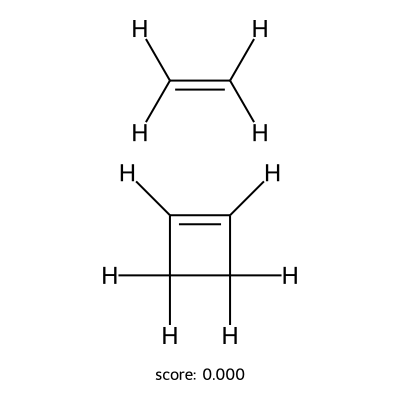

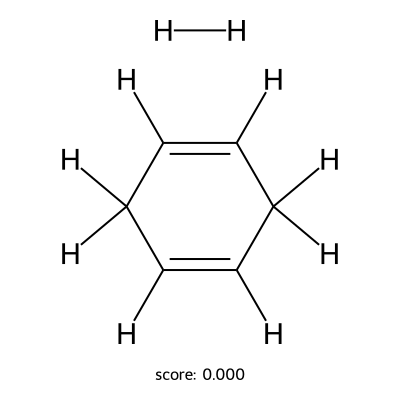

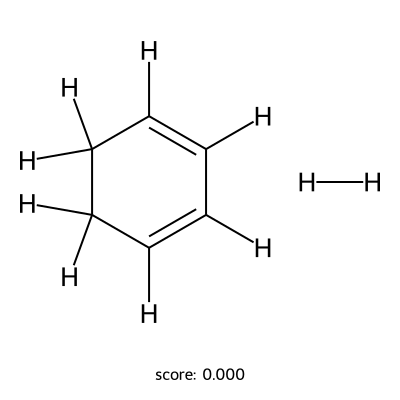

In [17]:
da_products = sorted(da_products, key=lambda mol: mol.bond_mat_scores[0])
print("Top 3 products before filtering:")
da_products[0].draw_bmats(show_inline=True)
da_products[1].draw_bmats(show_inline=True)
da_products[2].draw_bmats(show_inline=True)

Bottom 3 products before filtering


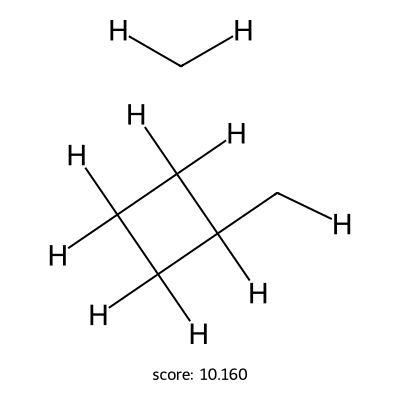

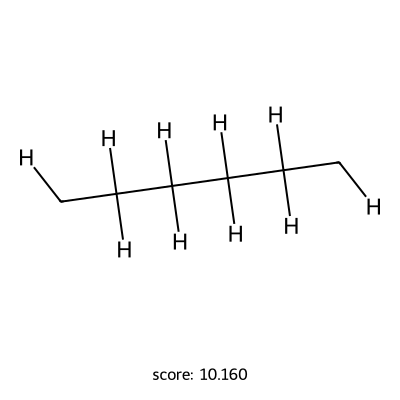

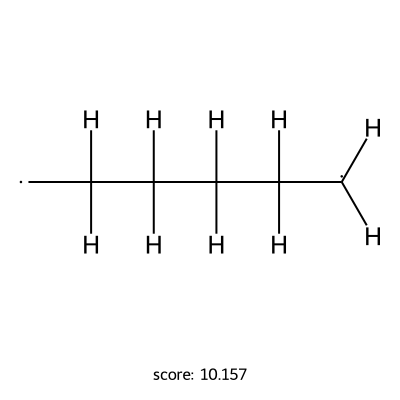

In [18]:
print("Bottom 3 products before filtering")
da_products[-1].draw_bmats(show_inline=True)
da_products[-2].draw_bmats(show_inline=True)
da_products[-3].draw_bmats(show_inline=True)

## Product filtering!

In [19]:
da_filtered_products = [_ for _ in da_products if _.bond_mat_scores[0]<=0.0 and sum(np.abs(_.fc))<=2.0]
print(f"We have {len(da_filtered_products)} products after filtering")

We have 46 products after filtering


Top 3 products after filtering:


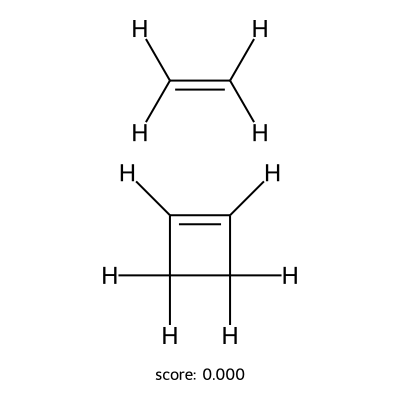

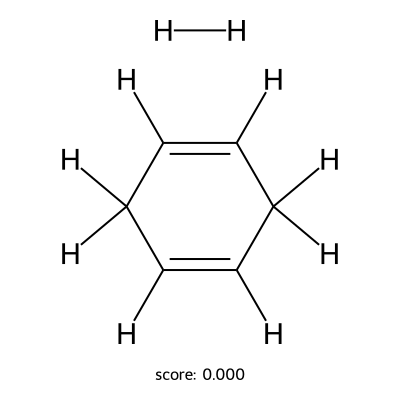

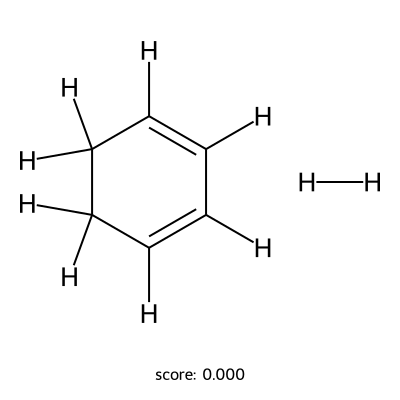

In [20]:
da_filtered_products = sorted(da_filtered_products, key=lambda mol: mol.bond_mat_scores[0])
print("Top 3 products after filtering:")
da_filtered_products[0].draw_bmats(show_inline=True)
da_filtered_products[1].draw_bmats(show_inline=True)
da_filtered_products[2].draw_bmats(show_inline=True)

Bottom 3 products after filtering


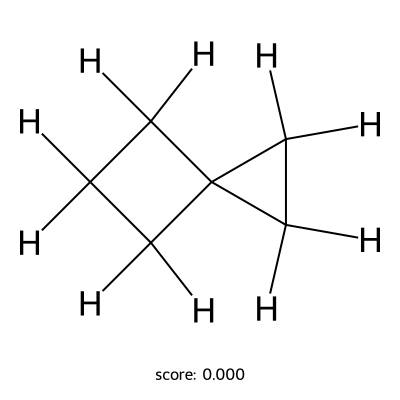

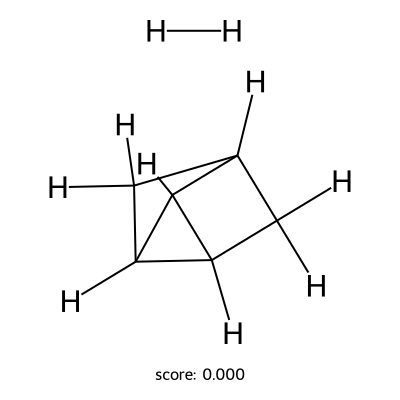

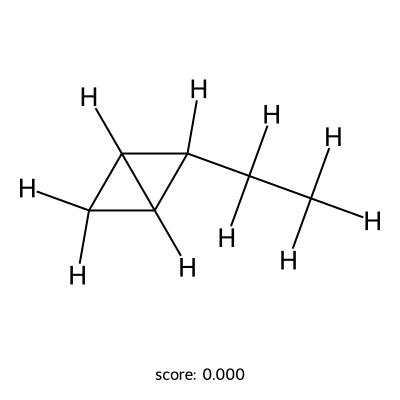

In [21]:
print("Bottom 3 products after filtering")
da_filtered_products[-1].draw_bmats(show_inline=True)
da_filtered_products[-2].draw_bmats(show_inline=True)
da_filtered_products[-3].draw_bmats(show_inline=True)

In [22]:
da_filtered_products_res = check_resonance(da_filtered_products)

Number of molecules with resonance structures: 0
Total resonance structures generated: 0


# A little more complicated - Benzene b2f2

## Bond breakage!

In [23]:
benz_break = list(break_bonds(benzene_mol, n=2))
print(f"We have {len(benz_break)} intermediates after break 2")

We have 18 intermediates after break 2


In [24]:
run_stats('list(break_bonds(benzene_mol, n=2))')

Wed Jul  2 14:27:01 2025    tmp.prof

         547187 function calls (510440 primitive calls) in 0.693 seconds

   Ordered by: cumulative time
   List reduced from 195 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.695    0.695 {built-in method builtins.exec}
        1    0.000    0.000    0.695    0.695 <string>:1(<module>)
       19    0.002    0.000    0.695    0.037 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:257(break_bonds)
      132    0.001    0.000    0.692    0.005 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
      132    0.001    0.000    0.601    0.005 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
      132    0.002    0.000    0.582    0.004 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/lewis_structure.py:80(__init__)
      132    0.010    0.000    0.475    0.004 /Users/erm/git_stuff/yarp-again/yarp/yarpe

In [25]:
benz_break_res = check_resonance(benz_break)

Number of molecules with resonance structures: 7
Total resonance structures generated: 14
  - Maximum N resonance structures: 2
  - Minimum N resonance structures: 2
  - Average N resonance structures: 2.0


## Bond formage!

In [26]:
benz_products = form_n_bonds(benz_break, n=2)
print(f"We have {len(benz_products)} products after form 2")

We have 768 products after form 2


In [27]:
run_stats('form_n_bonds(benz_break, n=2)')

Wed Jul  2 14:27:41 2025    tmp.prof

         24710767 function calls (21503762 primitive calls) in 25.766 seconds

   Ordered by: cumulative time
   List reduced from 208 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   25.833   25.833 {built-in method builtins.exec}
        1    0.006    0.006   25.833   25.833 <string>:1(<module>)
        1    0.011    0.011   25.827   25.827 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:153(form_n_bonds)
     1554    0.104    0.000   25.815    0.017 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:13(form_bonds)
     3983    0.020    0.000   25.640    0.006 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
     3983    0.026    0.000   17.808    0.004 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
     3983    0.064    0.000   17.191    0.004 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis

In [28]:
benz_products_res = check_resonance(benz_products)

Number of molecules with resonance structures: 167
Total resonance structures generated: 434
  - Maximum N resonance structures: 10
  - Minimum N resonance structures: 2
  - Average N resonance structures: 2.5988023952095807


## Product filtering!

In [29]:
benz_filtered_products = [_ for _ in benz_products if _.bond_mat_scores[0]<=0.0 and sum(np.abs(_.fc))<=2.0]
print(f"We have {len(benz_filtered_products)} products after filtering")

We have 88 products after filtering


In [30]:
benz_filtered_products_res = check_resonance(benz_filtered_products)

Number of molecules with resonance structures: 6
Total resonance structures generated: 36
  - Maximum N resonance structures: 10
  - Minimum N resonance structures: 4
  - Average N resonance structures: 6.0


# Lone pairs give problems? - Pyridine b2f2 test case

## Bond breakage!

In [31]:
nbenz_break = list(break_bonds(nbenz_mol, n=2))
print(f"We have {len(nbenz_break)} intermediates after break 2")

We have 40 intermediates after break 2


In [32]:
run_stats('list(break_bonds(nbenz_mol, n=2))', 50)

Wed Jul  2 14:27:46 2025    tmp.prof

         1801823 function calls (1777059 primitive calls) in 2.695 seconds

   Ordered by: cumulative time
   List reduced from 198 to 50 due to restriction <50>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    2.697    2.697 {built-in method builtins.exec}
        1    0.000    0.000    2.697    2.697 <string>:1(<module>)
       41    0.002    0.000    2.696    0.066 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:257(break_bonds)
      110    0.001    0.000    2.694    0.024 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
      110    0.001    0.000    2.632    0.024 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
      110    0.002    0.000    2.617    0.024 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/lewis_structure.py:80(__init__)
      110    0.009    0.000    2.537    0.023 /Users/erm/git_stuff/yarp-again/yarp/yar

In [33]:
nbenz_break_res = check_resonance(nbenz_break)

Number of molecules with resonance structures: 13
Total resonance structures generated: 31
  - Maximum N resonance structures: 4
  - Minimum N resonance structures: 2
  - Average N resonance structures: 2.3846153846153846


## Bond formage!

In [34]:
nbenz_products = form_n_bonds(nbenz_break, n=2)
print(f"We have {len(nbenz_products)} products after form 2")

We have 3729 products after form 2


In [35]:
run_stats('form_n_bonds(nbenz_break, n=2)')

Wed Jul  2 14:31:02 2025    tmp.prof

         102360063 function calls (91517297 primitive calls) in 124.630 seconds

   Ordered by: cumulative time
   List reduced from 211 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  124.877  124.877 {built-in method builtins.exec}
        1    0.031    0.031  124.877  124.877 <string>:1(<module>)
        1    0.049    0.049  124.847  124.847 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:153(form_n_bonds)
     7498    0.428    0.000  124.791    0.017 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:13(form_bonds)
    15274    0.088    0.000  124.072    0.008 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
    15274    0.107    0.000   96.525    0.006 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
    15274    0.272    0.000   94.034    0.006 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lew

In [36]:
nbenz_products_res = check_resonance(nbenz_products)

Number of molecules with resonance structures: 744
Total resonance structures generated: 2032
  - Maximum N resonance structures: 10
  - Minimum N resonance structures: 2
  - Average N resonance structures: 2.7311827956989245


## Product filtering!

In [37]:
nbenz_filtered_products = [_ for _ in nbenz_products if _.bond_mat_scores[0]<=0.0 and sum(np.abs(_.fc))<=2.0]
print(f"We have {len(nbenz_filtered_products)} products after filtering")

We have 284 products after filtering


In [38]:
nbenz_filtered_products_res = check_resonance(nbenz_filtered_products)

Number of molecules with resonance structures: 43
Total resonance structures generated: 172
  - Maximum N resonance structures: 10
  - Minimum N resonance structures: 2
  - Average N resonance structures: 4.0


# Bimolecular exploration: b2f2 enumeration from reactant side of Diels-Alder

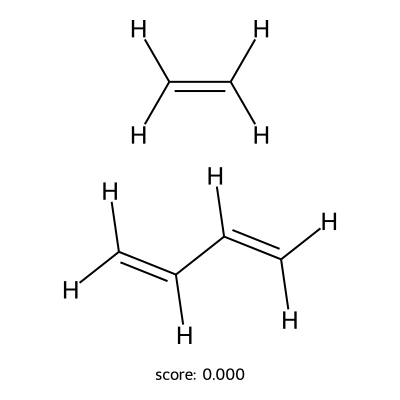

In [39]:
dar_smi = "C=C.C=CC=C"
dar_mol = yp.yarpecule(dar_smi)
dar_mol.draw_bmats(show_inline=True)

In [40]:
run_stats('yp.yarpecule(dar_smi)', 50)

Wed Jul  2 14:31:02 2025    tmp.prof

         5946 function calls (5702 primitive calls) in 0.019 seconds

   Ordered by: cumulative time
   List reduced from 189 to 50 due to restriction <50>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.019    0.019 {built-in method builtins.exec}
        1    0.000    0.000    0.019    0.019 <string>:1(<module>)
        1    0.000    0.000    0.019    0.019 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
        1    0.000    0.000    0.010    0.010 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
        1    0.000    0.000    0.010    0.010 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/lewis_structure.py:80(__init__)
        1    0.000    0.000    0.009    0.009 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/lewis_structure.py:127(_gen_bond_el_mat)
        1    0.000    0.000    0.008    0.008 /Users/erm/git_stuff/ya

## Bond breakage!

In [41]:
dar_break = list(break_bonds(dar_mol, n=2))
print(f"We have {len(dar_break)} intermediates after break 2")

We have 16 intermediates after break 2


In [42]:
run_stats('list(break_bonds(dar_mol, n=2))')

Wed Jul  2 14:31:03 2025    tmp.prof

         452759 function calls (432345 primitive calls) in 0.665 seconds

   Ordered by: cumulative time
   List reduced from 186 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.668    0.668 {built-in method builtins.exec}
        1    0.000    0.000    0.668    0.668 <string>:1(<module>)
       17    0.002    0.000    0.667    0.039 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:257(break_bonds)
      110    0.001    0.000    0.665    0.006 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
      110    0.001    0.000    0.600    0.005 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
      110    0.002    0.000    0.581    0.005 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis/lewis_structure.py:80(__init__)
      110    0.009    0.000    0.502    0.005 /Users/erm/git_stuff/yarp-again/yarp/yarpe

In [43]:
dar_break_res = check_resonance(dar_break)

Number of molecules with resonance structures: 2
Total resonance structures generated: 4
  - Maximum N resonance structures: 2
  - Minimum N resonance structures: 2
  - Average N resonance structures: 2.0


## Bond formage!

In [44]:
dar_products = form_n_bonds(dar_break, n=2)
print(f"We have {len(dar_products)} products after form 2")

We have 1300 products after form 2


In [45]:
run_stats('form_n_bonds(dar_break, n=2)')

Wed Jul  2 14:32:03 2025    tmp.prof

         34043708 function calls (29665336 primitive calls) in 37.630 seconds

   Ordered by: cumulative time
   List reduced from 207 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   37.771   37.771 {built-in method builtins.exec}
        1    0.032    0.032   37.771   37.771 <string>:1(<module>)
        1    0.021    0.021   37.739   37.739 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:153(form_n_bonds)
     2616    0.184    0.000   37.716    0.014 /Users/erm/git_stuff/yarp-again/yarp/reaction/enum.py:13(form_bonds)
     6672    0.037    0.000   37.407    0.006 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:80(__init__)
     6672    0.043    0.000   25.603    0.004 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/yarpecule.py:278(_gen_lewis_struct)
     6672    0.106    0.000   24.361    0.004 /Users/erm/git_stuff/yarp-again/yarp/yarpecule/lewis

In [46]:
dar_products_res = check_resonance(dar_products)

Number of molecules with resonance structures: 158
Total resonance structures generated: 334
  - Maximum N resonance structures: 4
  - Minimum N resonance structures: 2
  - Average N resonance structures: 2.1139240506329116


In [ ]:
c13_benz_smi = "c1c[c13]ccc1"
c13_benz_mol